In [1]:
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%config InlineBackend.figure_format = 'svg'

In [2]:
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'lines.linewidth': 2})

# EH Self Acceleration In Uniform Electric Field

In [3]:
L = 60 * np.pi
nx = 4000
dx = L / (nx - 1)

vmax_e = 10  # 速度最大值
nv_e = 2000
dv_e = 2 * vmax_e / (nv_e - 1)

vmax_i = 0.52185  # 速度最大值
nv_i = 2000
dv_i = 2 * vmax_i / (nv_i - 1)

x = np.linspace(0, L, num=nx, endpoint=True)
ve = np.linspace(-vmax_e, vmax_e, num=nv_e, endpoint=True)
vi = np.linspace(-vmax_i, vmax_i, num=nv_i, endpoint=True)
Ve, Xe = np.meshgrid(ve, x)
Vi, Xi = np.meshgrid(vi, x)

psi = 0.1
delta = 5
Ea = 0.0008
Ea_s = 5
Ea_e = 305

dt = 0.05
max_steps = 20000
data_steps = int(max_steps / 5)
data_num = int(max_steps / data_steps) + 1

path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008"
print(data_num)
print("real time = ", max_steps * dt)

6
real time =  1000.0


In [4]:
progesses = np.arange(0,data_num,1)

fe = []
fi = []

for progess in tqdm(progesses):
    fe_temp = np.loadtxt(os.path.join(path,"fe"+str(progess)))
    fe.append(fe_temp)
    fi_temp = np.loadtxt(os.path.join(path,"fi"+str(progess)))
    fi.append(fi_temp)

100%|██████████| 6/6 [00:08<00:00,  1.35s/it]


In [5]:
lve = np.linspace(fe[0].min(),fe[0].max(),num=25)
lvi = np.linspace(fi[0].min(),fi[0].max(),num=15)

In [6]:
H_unifE = 0.5 * Ve**2 - (psi * np.cosh((Xe - L / 2) / delta) ** (-2) - Ea * Xe)
H_withoutE = 0.5 * Ve**2 - (psi * np.cosh((Xe - L / 2) / delta) ** (-2))
vs_withoutE = np.sqrt(2 * psi * np.cosh((x - L / 2) / delta) ** (-2))

In [7]:
sep_line = 30*np.pi*Ea
print("sep_line = ", sep_line)

sep_line =  0.07539822368615504


C:\Users\RGuo\AppData\Local\Temp\ipykernel_24016\240602295.py:12: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x00000265A4AE3110>' will be ignored
  ax1cmp.set_rasterized(True)
C:\Users\RGuo\AppData\Local\Temp\ipykernel_24016\240602295.py:18: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x00000265A4AB22D0>' will be ignored
  ax2cmp.set_rasterized(True)
C:\Users\RGuo\AppData\Local\Temp\ipykernel_24016\240602295.py:23: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x00000265A4A838D0>' will be ignored
  ax3cmp.set_rasterized(True)


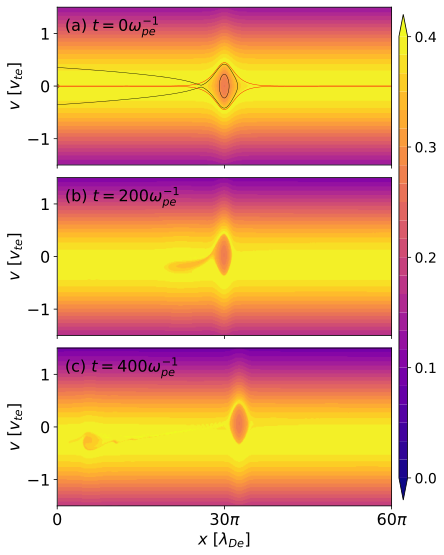

In [ ]:
x_ticks=[0, 15*np.pi, 30*np.pi, 45*np.pi, 60*np.pi]

fig,(ax1,ax2,ax3) = plt.subplots(figsize=(6, 9),ncols=1,nrows=3, sharex=True)

ax1cmp = ax1.contourf(Xe, Ve, fe[0], levels=lve,extend='both',cmap=cm.plasma)
ax1.contour(Xe, Ve, H_unifE, levels=[0.00085,0.063], colors='k', linewidths=0.4)
# ax1.contour(Xe, Ve, H_withoutE, levels=[0.0], colors='r', linewidths=0.4)
ax1.plot(x,  vs_withoutE, color='r', linewidth=0.4)
ax1.plot(x, -vs_withoutE, color='r', linewidth=0.4)
ax1.set_ylabel(r'$v~[v_{te}]$')
ax1.set_ylim(-1.5,1.5)
ax1cmp.set_rasterized(True)

ax2cmp = ax2.contourf(Xe, Ve, fe[1], levels=lve,extend='both',cmap=cm.plasma)
# ax2.contour(Xe, Ve, H, levels=[0.005,0.075,0.4], colors='k', linewidths=0.5, alpha=0.2)
ax2.set_ylabel(r'$v~[v_{te}]$')
ax2.set_ylim(-1.5,1.5)
ax2cmp.set_rasterized(True)

ax3cmp = ax3.contourf(Xe, Ve, fe[2], levels=lve,extend='both',cmap=cm.plasma)
ax3.set_ylabel(r'$v~[v_{te}]$')
ax3.set_ylim(-1.5,1.5)
ax3cmp.set_rasterized(True)

ax3.set_xlabel(r"$x~[\lambda_{De}]$")
ax3.set_xticks([0, 30*np.pi, 60*np.pi], ["0", r"$30\pi$", r"$60\pi$"])

ax1.text(0.023, 0.85, r'(a) $t=0 \omega_{pe}^{-1}$', transform=ax1.transAxes)
ax2.text(0.023, 0.85, r'(b) $t=200 \omega_{pe}^{-1}$', transform=ax2.transAxes)
ax3.text(0.023, 0.85, r'(c) $t=400 \omega_{pe}^{-1}$', transform=ax3.transAxes)

cax = fig.add_axes([0.917, 0.119, 0.02, 0.75])
cbar=fig.colorbar(ax1cmp, cax=cax, orientation='vertical',shrink=1.0,ticks=[0.0,0.1,0.2,0.3,0.4])
cbar.ax.tick_params(labelsize=14)

fig.subplots_adjust(wspace=0.4, hspace=0.08)
fig.align_ylabels()

# plt.savefig("fig6_fe_evo_uniformE00008.pdf", bbox_inches='tight', dpi=600)
plt.show()